In [1]:
#from data import load_data
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import evaluation

import OT
import poincare
import data
from load_data import *

/home/onyxia/work/OT_simulation_maladies/HGCN/load_data.py:67: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  profils_omim = profils_omim.reset_index()


In [2]:
embeddings = np.load('logs/2026_7_6/1/embeddings.npy')
print(embeddings.shape)

(19391, 50)


Text(0.5, 1.0, 'Training loss')

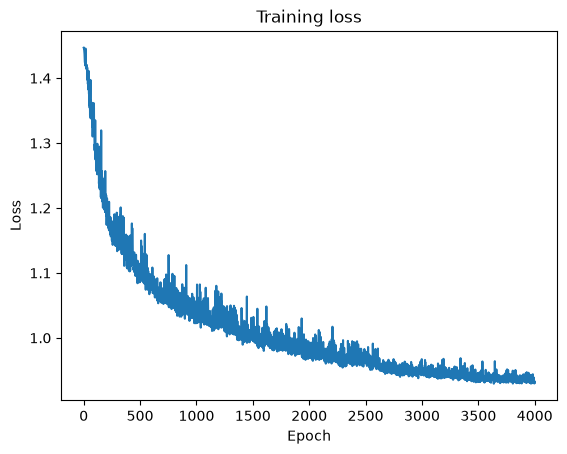

In [3]:
with open(os.path.join("logs/2026_7_6/1", 'metrics.json'), 'r') as f:
    results = json.load(f)

plt.plot(results['train_losses'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training loss')

Text(0, 0.5, 'MAP')

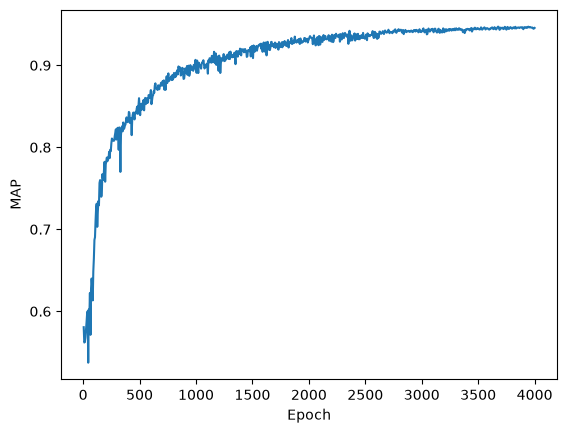

In [4]:
epochs = [m['epoch'] for m in results['val_metrics']]
maps = [m['roc'] for m in results['val_metrics']]  # ou 'ap' selon ce que retourne compute_metrics

plt.plot(epochs, maps)
plt.xlabel('Epoch')
plt.ylabel('MAP')

Text(0.5, 0, '||z||')

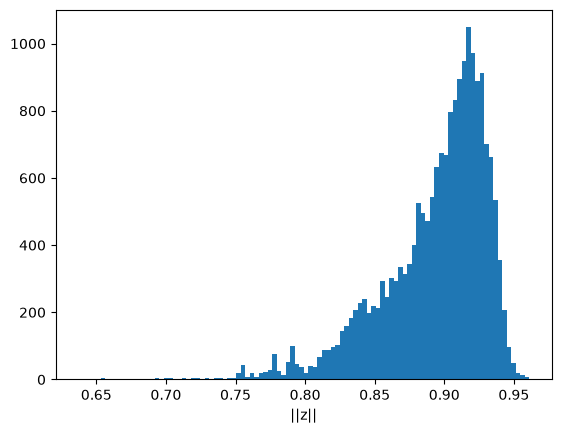

In [5]:
norms = np.linalg.norm(embeddings, axis=1)

plt.hist(norms, bins=100)
plt.xlabel('||z||')

In [6]:
manifold = poincare.PoincareManifold()
nodes = list(G_hpo_work.nodes())
node2idx = {n: i for i, n in enumerate(nodes)}

w_omim = work_omim.reset_index(drop=True)
w_orpha = work_orpha.reset_index(drop=True)
hpo_cols = [c for c in w_omim.columns if c.startswith('HP')]

ancestors = {hp: data.get_ancestors0(G_hpo_work, hp) for hp in hpo_cols}
w_omim_P = data.propagate_terms(w_omim,  hpo_cols, ancestors, depths, k=3)
w_orpha_P = data.propagate_terms(w_orpha, hpo_cols, ancestors, depths, k=3)

gt_set, valid_omim, valid_orpha = OT.f_ground_truth(w_omim, w_orpha, df_orpha_omim_exact)

In [8]:
union_diseases = data.add_corresponding_terms(w_omim, w_orpha, df_orpha_omim_exact)
S = data.node_similarity_score(union_diseases, G_hpo_work)

#C_batch = pd.read_csv("cost_wasserstein.csv")
#C_batch = C_batch.drop(columns='Unnamed: 0').to_numpy()

Fusion HPO: 100%|██████████| 2217/2217 [00:00<00:00, 8522.26it/s]


In [ ]:
C = OT.compute_costs_matrix_wasserstein2(w_omim, w_orpha, node2idx, embeddings, manifold, c=1., S=S)

Precompute...
Finished !
Precomputing full HPO distance matrix...


Distance matrix rows: 100%|██████████| 84/84 [00:40<00:00,  2.07it/s]


HPO distance matrix: (10649, 10649)


OMIM: 100%|██████████| 6562/6562 [21:45<00:00,  5.03it/s]


In [12]:
# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = OT.compute_transport(C_batch, a=None, b=None)
ranks, pairs = OT.evaluate_transport(ot_plan, gt_set, C_batch)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[1] * np.mean(C_batch)
print(epsilon)
ot_plan_reg, ot_cots_reg = OT.compute_transport_sinkhorn(C_batch, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, pairs_reg = OT.evaluate_transport(ot_plan_reg, gt_set, C_batch)

======== Sans régularisation ========
Paires évaluées : 2217
Top-1 accuracy : 0.460 (1020/2217)
Top-3 accuracy : 0.493 (1092/2217)
Top-5 accuracy : 0.493 (1093/2217)
 Rang moyen: 818.10
======== Avec régularisation ========
0.025476760123715258
Paires évaluées : 2217
Top-1 accuracy : 0.482 (1068/2217)
Top-3 accuracy : 0.607 (1345/2217)
Top-5 accuracy : 0.655 (1452/2217)
 Rang moyen: 49.52


In [9]:
C_batch = OT.compute_costs_matrix_wasserstein_batched(w_omim, w_orpha, node2idx, embeddings, manifold, c=1., S=S)

Precompute...
Finished !
Precomputing full HPO distance matrix...


Distance matrix rows: 100%|██████████| 84/84 [05:47<00:00,  4.14s/it]


HPO distance matrix: (10697, 10697)
129 tailles distinctes côté OMIM, 117 côté Orpha


Length groups (OMIM): 100%|██████████| 129/129 [14:13<00:00,  6.62s/it]


In [ ]:
# Pondération des maladies
import pandas as pd
import data

all_diseases =pd.concat([ld.work_omim, ld.work_orpha], ignore_index=True)
w, _, _ = OT.compute_information_content(all_diseases, ld.G_hpo_work)

n, m = len(ld.work_omim), len(ld.work_orpha)

def precompute(df):
    '''
    Renvoie pour chaque maladie (ligne) du dataframe df la liste des termes HPO actifs et 
    le vecteur de poids uniformes associés.
    '''
    hpo_cols = [c for c in df.columns if c.startswith('HP')]
    X = df[hpo_cols].to_numpy(dtype=bool)
    resolved_cols = np.array(
        [data.deprecated.get(col, col) if data.deprecated.get(col, col) in ld.node2id_w else None for col in hpo_cols], 
        dtype=object)
    valid_mask = resolved_cols != np.array(None)
    X_valid = X[:, valid_mask]
    resolved_valid = resolved_cols[valid_mask]
    terms = [list(resolved_valid[row_mask]) for row_mask in X_valid]
    return terms

active_omim = precompute(ld.work_omim)
active_orpha = precompute(ld.work_orpha)
def precompute_weights(active, w):
    ic  = {k:-np.log(t) for k,t in w.items()}
    a0 = np.zeros(len(active))
    a1 = np.zeros(len(active))
    for j in range(len(active)):
        terms = active[j]
        w_j = np.array([w[t] for t in terms])
        ic_j = np.array([ic[t] for t in terms])
        a0[j], a1[j] = np.mean(w_j), np.mean(ic_j)
    return a0/a0.sum(), a1/a1.sum()

a_omim, ic_omim = precompute_weights(active_omim, w)
b_orpha, ic_orpha = precompute_weights(active_orpha, w)

6562 6562
3189 3189


In [46]:
# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = OT.compute_transport(C, ic_omim, ic_orpha)
ranks, pairs = OT.evaluate_transport(ot_plan, gt_set, C)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[1] * np.mean(C)
print(epsilon)
ot_plan_reg, ot_cots_reg = OT.compute_transport_sinkhorn(C, ic_omim, ic_orpha, epsilon, 10000, 1e-4, False)
ranks_reg, pairs_reg = OT.evaluate_transport(ot_plan_reg, gt_set, C)

======== Sans régularisation ========
Paires évaluées : 2237
Top-1 accuracy : 0.378 (846/2237)
Top-3 accuracy : 0.413 (924/2237)
Top-5 accuracy : 0.414 (925/2237)
 Rang moyen: 944.62
======== Avec régularisation ========
0.11578572626100278
Paires évaluées : 2237
Top-1 accuracy : 0.397 (887/2237)
Top-3 accuracy : 0.517 (1156/2237)
Top-5 accuracy : 0.558 (1249/2237)
 Rang moyen: 86.57


In [12]:
# Pondération des termes dans le double transport
import pandas as pd

all_diseases =pd.concat([ld.work_omim, ld.work_orpha], ignore_index=True)

w, _, _ = OT.compute_information_content(all_diseases, ld.G_hpo_work)
ic = {k:-np.log(t) for k,t in w.items()}

#C_ic = OT.compute_costs_matrix_wasserstein2(ld.work_omim, ld.work_orpha, node2idx, embeddings, manifold, c=1., weights=ic)

In [9]:
print("======== Sans régularisation ========")
ot_plan, ot_cost = OT.compute_transport(C_ic, a=None, b=None)
ranks, pairs = OT.evaluate_transport(ot_plan, gt_set, C_ic)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[1] * np.mean(C_ic)
print(epsilon)
ot_plan_reg, ot_cots_reg = OT.compute_transport_sinkhorn(C_ic, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, pairs_reg = OT.evaluate_transport(ot_plan_reg, gt_set, C_ic)

======== Sans régularisation ========
Paires évaluées : 2237
Top-1 accuracy : 0.362 (810/2237)
Top-3 accuracy : 0.400 (895/2237)
Top-5 accuracy : 0.401 (898/2237)
 Rang moyen: 964.39
======== Avec régularisation ========
0.12026577286673287
Paires évaluées : 2237
Top-1 accuracy : 0.395 (884/2237)
Top-3 accuracy : 0.511 (1144/2237)
Top-5 accuracy : 0.563 (1260/2237)
 Rang moyen: 87.14


In [20]:
# Transport entre barycentres
C_bary = OT.compute_costs_barycenter(
    ld.work_omim, ld.work_orpha, node2idx, embeddings, data.deprecated, manifold)

print("======== Sans régularisation ========")
ot_plan, ot_cost = OT.compute_transport(C_bary, a=None, b=None)
ranks, pairs = OT.evaluate_transport(ot_plan, gt_set, C_bary)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[1] * np.mean(C_bary)
print(epsilon)
ot_plan_reg, ot_cots_reg = OT.compute_transport_sinkhorn(C_bary, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, pairs_reg = OT.evaluate_transport(ot_plan_reg, gt_set, C_bary)

Barycentres: 100%|██████████| 3189/3189 [01:34<00:00, 33.92it/s]


======== Sans régularisation ========
Paires évaluées : 2237
Top-1 accuracy : 0.028 (63/2237)
Top-3 accuracy : 0.037 (83/2237)
Top-5 accuracy : 0.039 (88/2237)
 Rang moyen: 1566.46
======== Avec régularisation ========
0.2809487846644238
Paires évaluées : 2237
Top-1 accuracy : 0.028 (63/2237)
Top-3 accuracy : 0.065 (146/2237)
Top-5 accuracy : 0.096 (215/2237)
 Rang moyen: 254.18


In [ ]:
work_omim0 = ld.work_omim[ld.work_omim['database_id'].isin(valid_omim)]
work_orpha0 = ld.work_orpha[ld.work_orpha['database_id'].isin(valid_orpha)]
work_omim0 = work_omim0.reset_index(drop=True)
work_orpha0 = work_orpha0.reset_index(drop=True)
hpo_cols0 = [c for c in work_omim0.columns if c.startswith("HP:")]

# ground_truth s'appuie sur les indices des maladies dans les datasets initiaux
gt_set_exact, valid_omim0, valid_orpha0 = OT.f_ground_truth(work_omim0, work_orpha0, ld.df_orpha_omim_exact)
C0 = OT.compute_costs_matrix_wasserstein2(work_omim0, work_orpha0, node2idx, embeddings, manifold, c=1.)

Precompute...
Finished !
Precomputing full HPO distance matrix...


Distance matrix rows: 100%|██████████| 34/34 [00:15<00:00,  2.16it/s]


HPO distance matrix: (8684, 8684)


OMIM: 100%|██████████| 2237/2237 [03:56<00:00,  9.48it/s]


In [ ]:
print("======== Sans régularisation ========")
ot_plan, ot_cost = OT.compute_transport(C0, a=None, b=None)
ranks, pairs = OT.evaluate_transport(ot_plan, gt_set_exact, C0)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[1] * np.mean(C0)
print(epsilon)
ot_plan_reg, ot_cots_reg = OT.compute_transport_sinkhorn(C0, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, pairs_reg = OT.evaluate_transport(ot_plan_reg, gt_set_exact, C0)

======== Sans régularisation ========
Paires évaluées : 2237
Top-1 accuracy : 0.446 (998/2237)
Top-3 accuracy : 0.447 (1000/2237)
Top-5 accuracy : 0.447 (1001/2237)
 Rang moyen: 613.15
======== Avec régularisation ========
0.11453635119644678
Paires évaluées : 2237
Top-1 accuracy : 0.437 (978/2237)
Top-3 accuracy : 0.561 (1254/2237)
Top-5 accuracy : 0.605 (1353/2237)
 Rang moyen: 51.34


In [20]:
communs = []
correct = []
for k, (i, j) in enumerate(gt_set):
    omim_row = w_omim.iloc[i][hpo_cols]
    orpha_row = w_orpha.iloc[j][hpo_cols]
    communs.append(len(set(omim_row)&set(orpha_row))/len(omim_row))
    if ranks_reg[k]==1:
        correct.append(1)
    else:
        correct.append(0)



In [22]:
communs

[0.0001722207870489968,
 0.0001722207870489968,
 0.0001722207870489968,
 0.0001722207870489968,
 0.0001722207870489968,
 0.0001722207870489968,
 0.0001722207870489968,
 0.0001722207870489968,
 0.0001722207870489968,
 0.0001722207870489968,
 0.0001722207870489968,
 0.0001722207870489968,
 0.0001722207870489968,
 0.0001722207870489968,
 0.0001722207870489968,
 0.0001722207870489968,
 0.0001722207870489968,
 0.0001722207870489968,
 0.0001722207870489968,
 0.0001722207870489968,
 0.0001722207870489968,
 0.0001722207870489968,
 0.0001722207870489968,
 0.0001722207870489968,
 0.0001722207870489968,
 0.0001722207870489968,
 0.0001722207870489968,
 0.0001722207870489968,
 0.0001722207870489968,
 0.0001722207870489968,
 0.0001722207870489968,
 0.0001722207870489968,
 0.0001722207870489968,
 0.0001722207870489968,
 0.0001722207870489968,
 0.0001722207870489968,
 0.0001722207870489968,
 0.0001722207870489968,
 0.0001722207870489968,
 0.0001722207870489968,
 0.0001722207870489968,
 0.0001722207870

## Evaluation

Train : 1773
 Test : 444
Accuracy : 0.739
Precision: 0.546
Recall   : 0.739


/opt/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


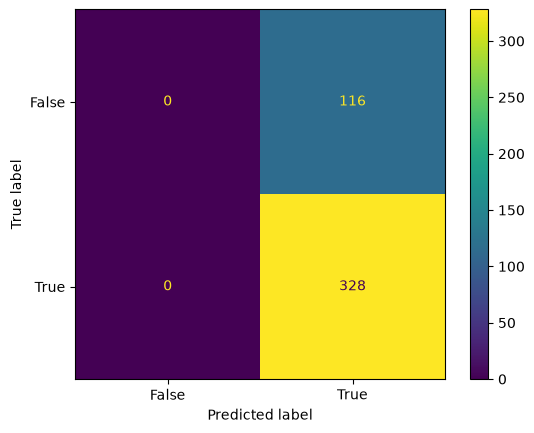

In [12]:
metrics = evaluation.logistic_reg(ot_plan_reg, gt_set, seed=12)

In [20]:
seuil_masse = evaluation.seuil_masse(ot_plan_reg, gt_set)
seuil_rang = evaluation.seuil_rang(ot_plan_reg, gt_set)
print(seuil_masse, seuil_rang)

Taille du jeu de calibration : 443
Taille du jeu de test : 1774
Taille du jeu de calibration : 443
Taille du jeu de test : 1774
[np.float64(0.9983349575601149), np.float64(0.999282856395609)] [np.float64(126.0), np.float64(351.4266365688488)]


## Intégration de l'information génétique

On aimerait bien voir ce que Gromov Wasserstein donne.

In [48]:
import ot.gromov as gm
from collections import defaultdict

def to_list(x):
    if isinstance(x, list):
        return [p for p in x if pd.notna(p)]
    elif pd.notna(x):
        return [x]
    else:
        return []

def simi_ppi(df):
    n = df.shape[0]
    protein_to_idx = defaultdict(list)
    for i, row in df.iterrows():
        for p in to_list(row['protein']):
            protein_to_idx[p].append(i)

    S = np.zeros((n, n))
    for i, row in df.iterrows():
        proteins2 = row['protein2'] if isinstance(row['protein2'], list) else []
        scores = row['combined_score'] if isinstance(row['combined_score'], list) else []
        for p, val in zip(proteins2, scores):
            if pd.isna(p) or pd.isna(val):
                continue
            for j in protein_to_idx.get(p, []):
                S[i, j] = val
                S[j, i] = val
    np.fill_diagonal(S, 1)
    return S

def simi_ppi_crossed(df1, df2):
    n = df1.shape[0]
    m = df2.shape[0]
    protein_to_idx1 = defaultdict(list)
    protein_to_idx2 = defaultdict(list)
    for i, row in df1.iterrows():
        proteins = row['protein'] if isinstance(row['protein'], list) else [row['protein']]
        for p in proteins:
            if pd.notna(p):
                protein_to_idx1[p].append(i)
    for j, row in df2.iterrows():
        proteins = row['protein'] if isinstance(row['protein'], list) else [row['protein']]
        for p in proteins:
            if pd.notna(p):
                protein_to_idx2[p].append(j)
    S = np.zeros((n, m))

    for i, row in df1.iterrows():
        interactions = list(row['protein2'])
        for p in interactions:
            list_j = protein_to_idx2.get(p)
            if list_j is not None :
                for j in list_j:
                    S[i, j]=1
    # Check
    S_transp = np.zeros((m, n))
    for j, row in df2.iterrows():
        interactions = list(row['protein2'])
        for p in interactions:
            list_i = protein_to_idx1.get(p)
            if list_i is not None:
                for i in list_i:
                    S_transp[j, i]=1
                    if S_transp[j, i]!=S[i, j]:
                        print("p", p)
                        print("i", i)
                        print(row)
    assert np.array_equal(S_transp.T, S), "Les deux matrices doivent être égales"
    return S, S_transp

In [49]:
orpha = list(set(work_orpha['database_id'])&set(df1_orpha.dropna()['disease_id'].unique())&set(df_orpha_omim_exact['orpha_id'].unique()))
omim = list(set(work_omim['database_id'])&set(df1_omim.dropna()['disease_id'].unique())&set(df_orpha_omim_exact['omim_id'].unique()))

omim_test = w_omim[w_omim['database_id'].isin(omim)].reset_index()
orpha_test = w_orpha[w_orpha['database_id'].isin(orpha)].reset_index()
print(omim_test.shape, orpha_test.shape)
gt_set_test, _, _ = OT.f_ground_truth(omim_test, orpha_test, df_orpha_omim_exact)
print(len(gt_set_test))

df1_omim0 = df1_omim[df1_omim['disease_id'].isin(omim)].dropna().reset_index(drop=True).reset_index()
df1_orpha0 = df1_orpha[df1_orpha['disease_id'].isin(orpha)].dropna().reset_index(drop=True).reset_index()

simi_source = simi_ppi(df1_omim0)
simi_target = simi_ppi(df1_orpha0)
simi_crossed, _ = simi_ppi_crossed(df1_omim0, df1_orpha0)

print(simi_source.shape)
print(simi_target.shape)
print(simi_crossed.shape)

(2686, 11615) (1673, 11615)
1545
(2686, 2686)
(1673, 1673)
(2686, 1673)


In [ ]:
# On retire les maladies qui ne sont similaires à aucune autre en termes de PPI (! En pratique, pas trop faisable)
print((simi_source.sum(axis=1) == 1).sum())
print((simi_target.sum(axis=1) == 1).sum())
print((simi_crossed.sum(axis=1) == 0).sum())
print((simi_crossed.sum(axis=0) == 0).sum())

sum_source = simi_source.sum(axis=1)
sum_target = simi_target.sum(axis=1)
sum_crossed1, sum_crossed0 = simi_crossed.sum(axis=1), simi_crossed.sum(axis=0)

line_omim = [i for i in range(simi_source.shape[0]) if sum_source[i]!=1]
line_orpha = [i for i in range(simi_target.shape[0]) if sum_target[i]!=1]
print(f"line_omim : {len(line_omim)}, line_orpha : {len(line_orpha)}")

simi_source_red = simi_source[np.ix_(line_omim, line_omim)]
simi_target_red = simi_target[np.ix_(line_orpha, line_orpha)]
print(simi_source_red.shape, simi_target_red.shape)

dif_source = 1-simi_source_red
dif_target = 1-simi_target_red

df1_omim00 = df1_omim0[df1_omim0['index'].isin(line_omim)]
df1_orpha00 = df1_orpha0[df1_orpha0['index'].isin(line_orpha)]
print(f"df1_omim00 : {df1_omim00.shape}, df1_orpha00 : {df1_orpha00.shape}")


157
94
196
73
line_omim : 2529, line_orpha : 1579
(2529, 2529) (1579, 1579)
df1_omim00 : (2529, 10), df1_orpha00 : (1579, 10)


In [42]:
df1_matrix_omim = df1_omim00.merge(
    omim_test.reset_index()[['database_id', 'index']].rename(columns={'index': 'omim_index'}),
    left_on='disease_id', right_on='database_id', how='left', suffixes=('', '_w')
)
df1_matrix_orpha = df1_orpha00.merge(
    orpha_test.reset_index()[['database_id', 'index']].rename(columns={'index': 'orpha_index'}),
    left_on='disease_id', right_on='database_id', how='left', suffixes=('', '_w')
)
print(df1_matrix_omim.shape, df1_matrix_orpha.shape)
omim_index = list(df1_matrix_omim['omim_index'])
orpha_index = list(df1_matrix_orpha['orpha_index'])

C_red = C_batch[np.ix_(omim_index, orpha_index)]

gt_set_gm, _, _ = OT.f_ground_truth(
    w_omim.iloc[omim_index].reset_index(), 
    w_orpha.iloc[orpha_index].reset_index(), df_orpha_omim_exact)
len(gt_set_gm)

(2529, 12) (1579, 12)


1440

In [47]:
C1_batch = OT.compute_costs_matrix_wasserstein_batched(
    w_omim.iloc[omim_index].reset_index(), 
    w_omim.iloc[omim_index].reset_index(), 
    node2idx, embeddings, manifold, c=1.)

Precompute...
Finished !
Precomputing full HPO distance matrix...


Distance matrix rows: 100%|██████████| 55/55 [00:19<00:00,  2.83it/s]


HPO distance matrix: (6995, 6995)
115 tailles distinctes côté OMIM, 115 côté Orpha


Length groups (OMIM):  87%|████████▋ | 100/115 [06:48<01:01,  4.08s/it]


KeyboardInterrupt: 

In [ ]:
C2_batch = OT.compute_costs_matrix_wasserstein_batched(
    w_orpha.iloc[orpha_index].reset_index(),
    w_orpha.iloc[orpha_index].reset_index(),
    node2idx, embeddings, manifold, c=1.
)

In [45]:
C_red_norm = C_red / C_red.max()
for eps in [0.01, 0.1, 1, 10]:
    ot_fgw = gm.entropic_fused_gromov_wasserstein(C_red_norm, dif_source, dif_target, epsilon=eps, alpha=0.5, loss_fun='kl_loss', max_iter=10e6, verbose=True)
    ranks, pairs = OT.evaluate_transport(ot_fgw, gt_set_gm, None)

/opt/python/lib/python3.13/site-packages/ot/backend.py:1206: RuntimeWarning: invalid value encountered in log
  return np.log(a)
/opt/python/lib/python3.13/site-packages/ot/bregman/_sinkhorn.py:642: UserWarning: Warning: numerical errors at iteration 0
  warnings.warn("Warning: numerical errors at iteration %d" % ii)


It.  |Err         
-------------------
    0|     nan|
Paires évaluées : 1440
Top-1 accuracy : 0.001 (1/1440)
Top-3 accuracy : 0.002 (3/1440)
Top-5 accuracy : 0.003 (5/1440)
 Rang moyen: 797.71
It.  |Err         
-------------------
    0|     nan|
Paires évaluées : 1440
Top-1 accuracy : 0.001 (1/1440)
Top-3 accuracy : 0.002 (3/1440)
Top-5 accuracy : 0.003 (5/1440)
 Rang moyen: 797.71
It.  |Err         
-------------------
    0|     nan|
Paires évaluées : 1440
Top-1 accuracy : 0.001 (1/1440)
Top-3 accuracy : 0.002 (3/1440)
Top-5 accuracy : 0.003 (5/1440)
 Rang moyen: 797.71
It.  |Err         
-------------------
    0|     nan|
Paires évaluées : 1440
Top-1 accuracy : 0.001 (1/1440)
Top-3 accuracy : 0.002 (3/1440)
Top-5 accuracy : 0.003 (5/1440)
 Rang moyen: 797.71
